In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset,DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [ ]:
# set random seeds for reproducbility
torch.manual_seed(42)

In [ ]:
# check for gpu
device="cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device:{device}")

Using device:cuda


In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "fashion-mnist_test.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "zalando-research/fashionmnist",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

df.head()

/tmp/ipykernel_1072/2172268890.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'fashionmnist' dataset.


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.shape

(10000, 785)

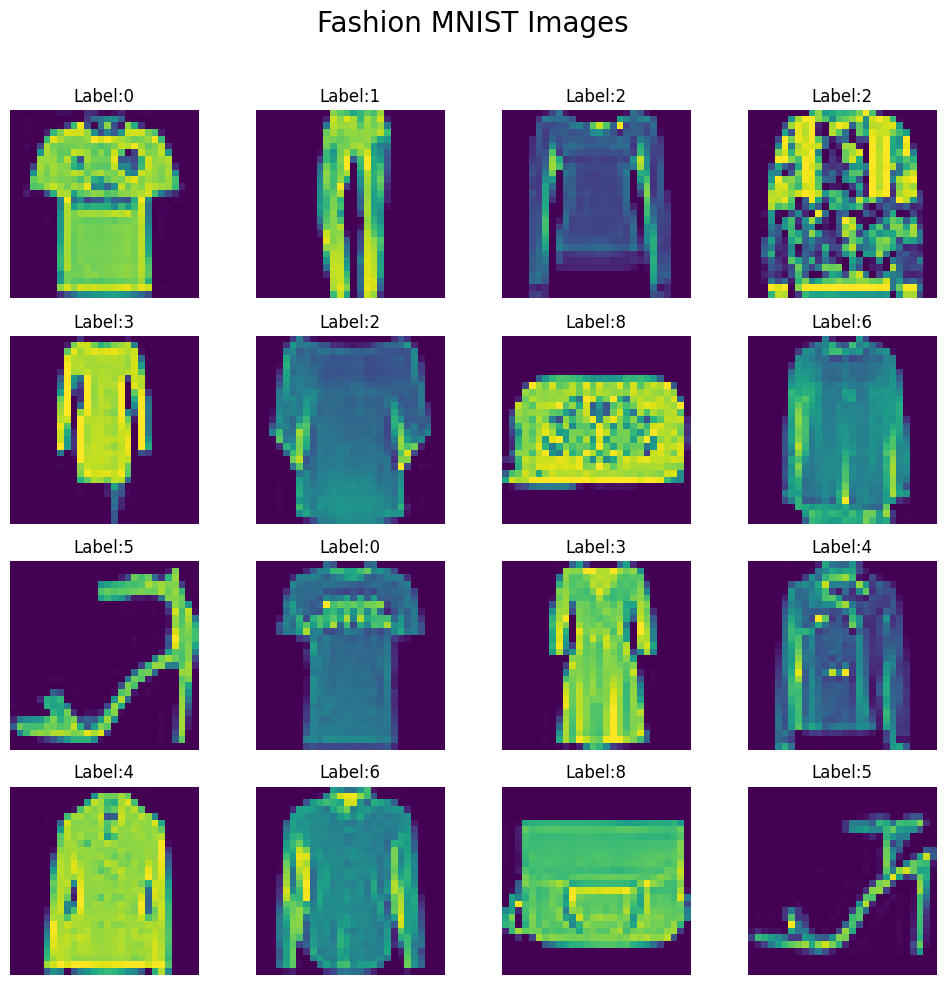

In [ ]:
# create a 4*4 grid of images
fig,axes=plt.subplots(4,4,figsize=(10,10))
fig.suptitle("Fashion MNIST Images",fontsize=20)

# Plot the first 16 images from the dataset
for i,ax in enumerate(axes.flat):
  img=df.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img)
  ax.axis('off')
  ax.set_title(f"Label:{df.iloc[i,0]}")

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

In [ ]:
# train test split
X=df.iloc[:,1:].values
y=df.iloc[:,0].values

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [ ]:
X_train=X_train/255.0
X_test=X_test/255.0

In [ ]:
class CustomDataset(Dataset):
  def __init__(self,features,labels) -> None:

    # convert to pytorch tensors
    self.features=torch.tensor(features,dtype=torch.float32)
    self.labels=torch.tensor(labels,dtype=torch.long)
  def __len__(self):
    return len(self.features)
  def __getitem__(self,idx):
    return self.features[idx],self.labels[idx]

In [ ]:
train_dataset=CustomDataset(X_train,y_train)
test_dataset=CustomDataset(X_test,y_test)

In [ ]:
len(train_dataset),len(test_dataset)

(8000, 2000)

In [ ]:
train_loader=DataLoader(train_dataset,batch_size=64,shuffle=True,pin_memory=True)
test_loader=DataLoader(test_dataset,batch_size=64,shuffle=False,pin_memory=True)

In [ ]:
len(train_loader),len(test_loader)

(125, 32)

In [ ]:
class MyNN(nn.Module):
  def __init__(self,num_features):
    super().__init__()

    self.model=nn.Sequential(nn.Linear(num_features,128),
                             nn.BatchNorm1d(128),
                             nn.ReLU(),
                             nn.Dropout(p=0.3),
                             nn.Linear(128,64),
                             nn.BatchNorm1d(64),
                             nn.ReLU(),
                             nn.Dropout(p=0.3),
                             nn.Linear(64,10))
  def forward(self,x):
    return self.model(x)

In [ ]:
learning_rate=0.01
epochs=100

In [ ]:
model=MyNN(X_train.shape[1])
model.to(device)

criterion=nn.CrossEntropyLoss()
optimizer=optim.SGD(model.parameters(),lr=learning_rate,weight_decay=1e-4)

In [ ]:
# training loop
for epoch in range(epochs):
  total_epoch_loss=0

  for batch_features,batch_labels in train_loader:

    # move data to gpu
    batch_features,batch_labels=batch_features.to(device),batch_labels.to(device)

    # forward pass
    outputs=model(batch_features)

    # calculate loss
    loss=criterion(outputs,batch_labels)

    # back pass
    optimizer.zero_grad()
    loss.backward()

    # update grads
    optimizer.step()

    total_epoch_loss +=loss.item()
  avg_loss=total_epoch_loss/len(train_loader)
  print(f"Epoch:{epoch+1}/{epochs}, Loss:{avg_loss:.4f}")

Epoch:1/100, Loss:1.5126
Epoch:2/100, Loss:1.0612
Epoch:3/100, Loss:0.8874
Epoch:4/100, Loss:0.7778
Epoch:5/100, Loss:0.7168
Epoch:6/100, Loss:0.6546
Epoch:7/100, Loss:0.6205
Epoch:8/100, Loss:0.5933
Epoch:9/100, Loss:0.5712
Epoch:10/100, Loss:0.5451
Epoch:11/100, Loss:0.5311
Epoch:12/100, Loss:0.5224
Epoch:13/100, Loss:0.5075
Epoch:14/100, Loss:0.4794
Epoch:15/100, Loss:0.4828
Epoch:16/100, Loss:0.4670
Epoch:17/100, Loss:0.4566
Epoch:18/100, Loss:0.4461
Epoch:19/100, Loss:0.4336
Epoch:20/100, Loss:0.4308
Epoch:21/100, Loss:0.4236
Epoch:22/100, Loss:0.4199
Epoch:23/100, Loss:0.4034
Epoch:24/100, Loss:0.4057
Epoch:25/100, Loss:0.3988
Epoch:26/100, Loss:0.3872
Epoch:27/100, Loss:0.3903
Epoch:28/100, Loss:0.3749
Epoch:29/100, Loss:0.3647
Epoch:30/100, Loss:0.3565
Epoch:31/100, Loss:0.3562
Epoch:32/100, Loss:0.3488
Epoch:33/100, Loss:0.3554
Epoch:34/100, Loss:0.3382
Epoch:35/100, Loss:0.3366
Epoch:36/100, Loss:0.3431
Epoch:37/100, Loss:0.3257
Epoch:38/100, Loss:0.3193
Epoch:39/100, Loss:0.

In [ ]:
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [ ]:
# Evaluation on test data
total=0
correct=0

with torch.no_grad():
  for batch_features,batch_labels in test_loader:
    batch_features,batch_labels=batch_features.to(device),batch_labels.to(device)

    outputs=model(batch_features)
    _,predicted=torch.max(outputs.data,1)
    total+=batch_labels.size(0)
    correct+=(predicted==batch_labels).sum().item()

accuracy=100*correct/total

In [ ]:
accuracy

85.6

In [ ]:
# evaluation on training data
total=0
correct=0

with torch.no_grad():
  for batch_features,batch_labels in train_loader:
    batch_features,batch_labels=batch_features.to(device),batch_labels.to(device)

    outputs=model(batch_features)
    _,predicted=torch.max(outputs.data,1)
    total+=batch_labels.size(0)

    correct=correct+(predicted==batch_labels).sum().item()

accuracy=100*correct/total
accuracy

98.6